# Construction Site Safety Monitoring System
## Custom YOLOv8 PPE Detection — 10 Classes

| ID | Class | ID | Class |
|----|-------|----|-------|
| 0 | ✅ Gloves | 5 | ❌ No-Goggles |
| 1 | ✅ Goggles | 6 | ❌ No-Helmet |
| 2 | ✅ Helmet | 7 | ❌ No-Mask |
| 3 | ✅ Mask | 8 | ❌ No-Safety-Vest |
| 4 | ❌ No-Gloves | 9 | ✅ Safety-Vest |

**Author:** Katlego Mathebula  
**Project:** AI-Powered PPE Detection System

## Cell 1 — Install and Import Libraries

In [2]:
# Install YOLOv8 (only need to run once)
!pip install ultralytics --quiet

import os
import yaml
import shutil
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from ultralytics import YOLO
from collections import Counter
from IPython.display import display, Image

print('All libraries imported successfully!')

All libraries imported successfully!


## Cell 2 — Define Classes & Paths

In [3]:
# ═══════════════════════════════════════════════════════════
# YOUR 10 PPE CLASSES — exactly as labelled in Roboflow
# ═══════════════════════════════════════════════════════════
PPE_CLASSES = [
    'Gloves',        # 0   wearing gloves
    'Goggles',       # 1   wearing goggles
    'Helmet',        # 2   wearing helmet
    'Mask',          # 3   wearing mask
    'No-Gloves',     # 4   violation
    'No-Goggles',    # 5   violation
    'No-Helmet',     # 6   violation
    'No-Mask',       # 7   violation
    'No-Safety-Vest',# 8   violation
    'Safety-Vest',   # 9   wearing vest
]

COMPLIANT = ['Gloves', 'Goggles', 'Helmet', 'Mask', 'Safety-Vest']
VIOLATION = ['No-Gloves', 'No-Goggles', 'No-Helmet', 'No-Mask', 'No-Safety-Vest']

# ── Paths ────────────────────────────────────────────────────
BASE_PATH    = r'c:/Users/User/OneDrive/DecodeLabs Internship/Project 4 -PPE_dectection'
DATASET_PATH = os.path.join(BASE_PATH, 'Dataset')
DATA_YAML    = os.path.join(DATASET_PATH, 'data.yaml')
OUTPUT_PATH  = os.path.join(BASE_PATH, 'Output')
MODELS_PATH  = os.path.join(BASE_PATH, 'Models')

# ── Write/update data.yaml with your 10 classes ─────────────
data_yaml_content = {
    'train' : os.path.join(DATASET_PATH, 'train', 'images'),
    'val'   : os.path.join(DATASET_PATH, 'valid', 'images'),
    'test'  : os.path.join(DATASET_PATH, 'test',  'images'),
    'nc'    : len(PPE_CLASSES),
    'names' : PPE_CLASSES,
}

with open(DATA_YAML, 'w') as f:
    yaml.dump(data_yaml_content, f, default_flow_style=False, allow_unicode=True)

print(f' data.yaml written!')
print(f'   Classes ({len(PPE_CLASSES)}): {PPE_CLASSES}')
print(f'   Dataset : {DATASET_PATH}')
print(f'   Output  : {OUTPUT_PATH}')

 data.yaml written!
   Classes (10): ['Gloves', 'Goggles', 'Helmet', 'Mask', 'No-Gloves', 'No-Goggles', 'No-Helmet', 'No-Mask', 'No-Safety-Vest', 'Safety-Vest']
   Dataset : c:/Users/User/OneDrive/DecodeLabs Internship/Project 4 -PPE_dectection\Dataset
   Output  : c:/Users/User/OneDrive/DecodeLabs Internship/Project 4 -PPE_dectection\Output


## Cell 3 — Verify Dataset & Class Distribution

In [4]:
print('=' * 55)
print('  DATASET VERIFICATION')
print('=' * 55)

total_counter = Counter()

for split in ['train', 'valid', 'test']:
    img_dir = os.path.join(DATASET_PATH, split, 'images')
    lbl_dir = os.path.join(DATASET_PATH, split, 'labels')
    imgs = len(os.listdir(img_dir)) if os.path.exists(img_dir) else 0
    lbls = len(os.listdir(lbl_dir)) if os.path.exists(lbl_dir) else 0
    print(f'\n  {split.upper():6s} → {imgs:4d} images  |  {lbls:4d} label files')

    split_counter = Counter()
    if os.path.exists(lbl_dir):
        for lbl_file in os.listdir(lbl_dir):
            if not lbl_file.endswith('.txt'):
                continue
            with open(os.path.join(lbl_dir, lbl_file)) as f:
                for line in f:
                    parts = line.strip().split()
                    if parts:
                        cls_id = int(parts[0])
                        split_counter[cls_id] += 1
                        total_counter[cls_id] += 1

    print(f'  Class distribution:')
    for cls_id, count in sorted(split_counter.items()):
        name   = PPE_CLASSES[cls_id] if cls_id < len(PPE_CLASSES) else f'UNKNOWN-{cls_id}'
        icon   = '✅' if name in COMPLIANT else '❌'
        bar    = '█' * min(count // 10, 25)
        print(f'    {icon} [{cls_id}] {name:20s} {count:5d}  {bar}')

print(f'\n{"=" * 55}')
print('  TOTAL ANNOTATIONS ACROSS ALL SPLITS:')
print(f'  {"=" * 53}')
for cls_id, count in sorted(total_counter.items()):
    name   = PPE_CLASSES[cls_id] if cls_id < len(PPE_CLASSES) else f'UNKNOWN-{cls_id}'
    icon   = '✅' if name in COMPLIANT else '❌'
    status = '🔥' if count > 300 else '✅' if count >= 100 else '⚠️'
    bar    = '█' * min(count // 20, 25)
    print(f'  {status} [{cls_id}] {name:20s} {count:5d}  {bar}')
print(f'\n  Total annotations : {sum(total_counter.values()):,}')
print(f'  Total classes     : {len(total_counter)} / {len(PPE_CLASSES)}')
print('=' * 55)
if len(total_counter) == len(PPE_CLASSES):
    print('  ✅ All 10 classes present — ready to train!')
else:
    missing = [PPE_CLASSES[i] for i in range(len(PPE_CLASSES)) if i not in total_counter]
    print(f'  ⚠️  Missing classes: {missing}')

  DATASET VERIFICATION

  TRAIN  →  581 images  |   581 label files
  Class distribution:
    ✅ [0] Gloves                 421  █████████████████████████
    ✅ [1] Goggles                210  █████████████████████
    ✅ [2] Helmet                 726  █████████████████████████
    ✅ [3] Mask                   355  █████████████████████████
    ❌ [4] No-Gloves              403  █████████████████████████
    ❌ [5] No-Goggles             390  █████████████████████████
    ❌ [6] No-Helmet              381  █████████████████████████
    ❌ [7] No-Mask                388  █████████████████████████
    ❌ [8] No-Safety-Vest         593  █████████████████████████
    ✅ [9] Safety-Vest            494  █████████████████████████

  VALID  →  116 images  |   116 label files
  Class distribution:
    ✅ [0] Gloves                  85  ████████
    ✅ [1] Goggles                 40  ████
    ✅ [2] Helmet                 146  ██████████████
    ✅ [3] Mask                    48  ████
    ❌ [4] No-Gloves  

## Cell 4 — Preview Training Images

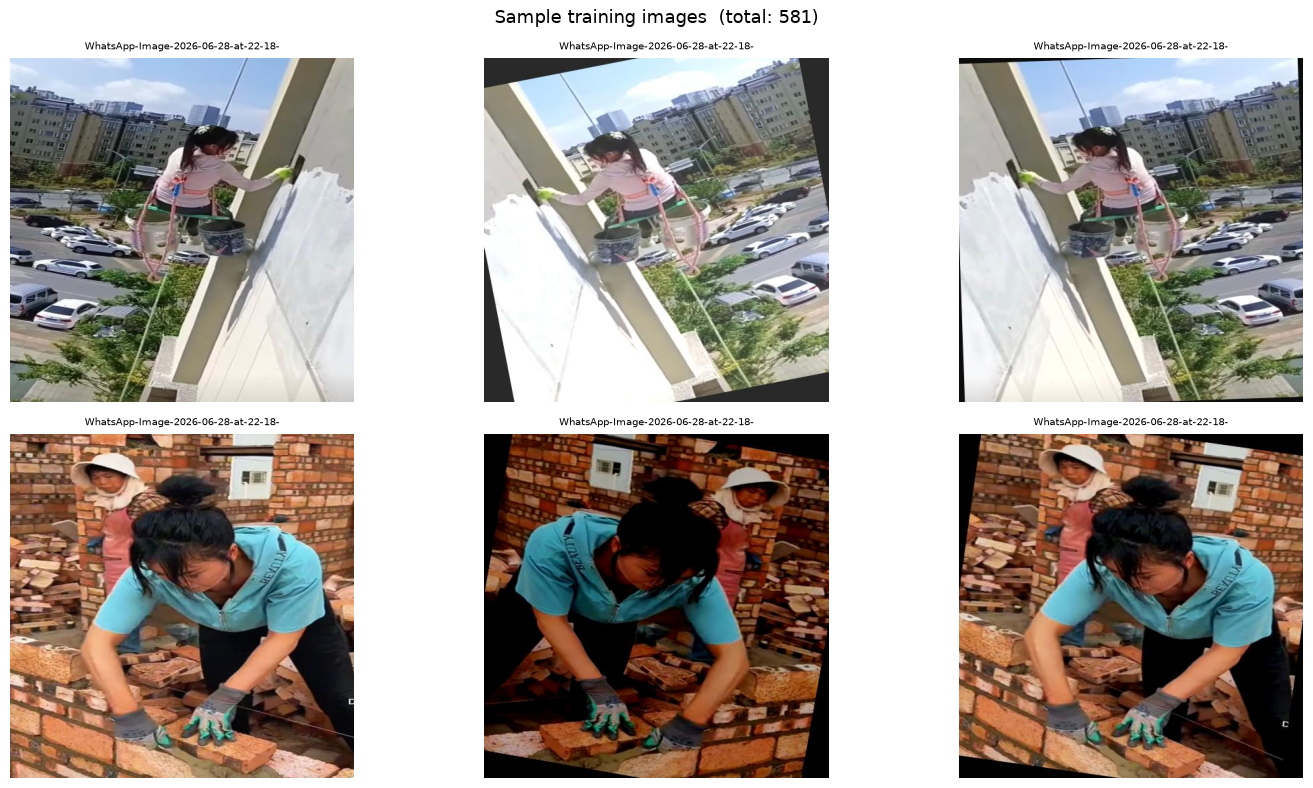

In [5]:
train_img_dir = os.path.join(DATASET_PATH, 'train', 'images')
all_imgs = [f for f in os.listdir(train_img_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

sample = all_imgs[:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(f'Sample training images  (total: {len(all_imgs)})', fontsize=13)

for ax, img_name in zip(axes.flatten(), sample):
    img = mpimg.imread(os.path.join(train_img_dir, img_name))
    ax.imshow(img)
    ax.set_title(img_name[:35], fontsize=7)
    ax.axis('off')

for ax in axes.flatten()[len(sample):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

## Cell 5 — TRAIN THE MODEL

In [ ]:
# ═══════════════════════════════════════════════════════════
# TRAINING CONFIGURATION (FINE-TUNING FROM EXISTING best.pt)
# ═══════════════════════════════════════════════════════════
MODEL_SIZE = r"c:\Users\User\OneDrive\DecodeLabs Internship\Project 4 -PPE_dectection\Output\ppe_10class-3\weights\best.pt"
# Loads the previously trained weights instead of a fresh yolov8s.pt,
# so training continues from what the model already learned.

EPOCHS     = 30              # fewer epochs needed since this is fine-tuning, not training from scratch
IMG_SIZE   = 640              # matches the resize setting used in the updated dataset (v4)
BATCH_SIZE = 2                # kept the same as the original run for CPU stability
RUN_NAME   = 'ppe_10class_finetuned'   # separate output folder, keeps the original ppe_10class-3 results intact
DEVICE     = 'cpu'            # change to 0 if a GPU becomes available
# ═══════════════════════════════════════════════════════════

print('Starting PPE Detection Fine-Tuning')
print('=' * 50)
print(f'  Base weights : {MODEL_SIZE}')
print(f'  Classes      : {len(PPE_CLASSES)} -> {PPE_CLASSES}')
print(f'  Epochs       : {EPOCHS}')
print(f'  Image size   : {IMG_SIZE}px')
print(f'  Batch size   : {BATCH_SIZE}')
print(f'  Device       : {DEVICE}')
print(f'  Output       : {OUTPUT_PATH}/{RUN_NAME}')
print('=' * 50)
print()

model = YOLO(MODEL_SIZE)

results = model.train(
    data      = DATA_YAML,     # must point to the NEW v4 data.yaml, not the original dataset
    epochs    = EPOCHS,
    imgsz     = IMG_SIZE,
    batch     = BATCH_SIZE,
    project   = OUTPUT_PATH,
    name      = RUN_NAME,
    device    = DEVICE,
    patience  = 10,             # slightly lower patience since fine-tuning converges faster
    save      = True,
    plots     = True,
    verbose   = True,
    workers   = 0,              # required to be 0 on Windows
    # Augmentation
    flipud    = 0.0,
    fliplr    = 0.5,
    mosaic    = 1.0,
    degrees   = 10.0,
    translate = 0.1,
    scale     = 0.5,
)

print('\nFine-tuning complete!')
print(f'   Best weights -> {OUTPUT_PATH}/{RUN_NAME}/weights/best.pt')

Starting PPE Detection Training
  Model      : yolov8s.pt
  Classes    : 10 → ['Gloves', 'Goggles', 'Helmet', 'Mask', 'No-Gloves', 'No-Goggles', 'No-Helmet', 'No-Mask', 'No-Safety-Vest', 'Safety-Vest']
  Epochs     : 50
  Image size : 416px
  Batch size : 2
  Device     : cpu
  Output     : c:/Users/User/OneDrive/DecodeLabs Internship/Project 4 -PPE_dectection\Output/ppe_10class

Ultralytics 8.4.75  Python-3.13.5 torch-2.12.1+cpu CPU (11th Gen Intel Core i3-1115G4 @ 3.00GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:/Users/User/OneDrive/DecodeLabs Internship/Project 4 -PPE_dectection\Dataset\data.yaml, degrees=10.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, eras

## Cell 6 — Evaluate Model on Test Set

In [6]:
BEST_WEIGHTS = os.path.join(OUTPUT_PATH, RUN_NAME, 'weights', 'best.pt')

if not os.path.exists(BEST_WEIGHTS):
    print(f'Weights not found at {BEST_WEIGHTS}')
    print('Did training complete? Check the Output folder.')
else:
    trained_model = YOLO(BEST_WEIGHTS)
    print('Evaluating on test set...')

    metrics = trained_model.val(
        data  = DATA_YAML,
        split = 'test',
        imgsz = IMG_SIZE
    )

    print('\n' + '=' * 55)
    print('  MODEL EVALUATION - 10-CLASS PPE DETECTION')
    print('=' * 55)
    print(f'  mAP@50       : {metrics.box.map50:.3f}   (target > 0.70)')
    print(f'  mAP@50-95    : {metrics.box.map:.3f}')
    print(f'  Precision    : {metrics.box.mp:.3f}')
    print(f'  Recall       : {metrics.box.mr:.3f}')
    print('=' * 55)

    print('\n  Per-class AP@50:')
    if hasattr(metrics.box, 'ap50') and metrics.box.ap50 is not None:
        for i, (cls_name, ap) in enumerate(zip(PPE_CLASSES, metrics.box.ap50)):
            category = 'COMPLIANT' if cls_name in COMPLIANT else 'VIOLATION'
            if ap >= 0.8:
                level = 'STRONG '
            elif ap >= 0.6:
                level = 'OK     '
            else:
                level = 'WEAK   '
            bar = '#' * int(ap * 20)
            print(f'  [{level}] [{category:9s}] [{i}] {cls_name:20s} {ap:.3f}  {bar}')

NameError: name 'RUN_NAME' is not defined

## Cell 7 — View Training Charts

In [7]:
results_chart = os.path.join(OUTPUT_PATH, RUN_NAME, 'results.png')

if os.path.exists(results_chart):
    img = mpimg.imread(results_chart)
    plt.figure(figsize=(18, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Training results — loss · precision · recall · mAP', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print(f'Chart not found: {results_chart}')
    print('Run Cell 5 (training) first.')

Chart not found: c:/Users/User/OneDrive/DecodeLabs Internship/Project 4 -PPE_dectection\Output\ppe_10class\results.png
Run Cell 5 (training) first.


## Cell 8 — Run Detection on Test Images

In [ ]:
import glob

test_dir  = os.path.join(DATASET_PATH, 'test', 'images')
test_imgs = glob.glob(os.path.join(test_dir, '*.jpg'))[:8]

print(f'Running detection on {len(test_imgs)} test images...')

pred_results = trained_model.predict(
    source     = test_imgs,
    conf       = 0.40,
    save       = True,
    project    = OUTPUT_PATH,
    name       = 'predictions',
    line_width = 2,
    exist_ok   = True,
    verbose    = False
)

print('\n' + '=' * 55)
print('  PPE DETECTION RESULTS')
print('=' * 55)

total_violations = 0

for i, r in enumerate(pred_results):
    img_name = os.path.basename(r.path)
    print(f'\n  {img_name}')
    if len(r.boxes) == 0:
        print('     No detections')
        continue
    for box in r.boxes:
        cls_name = PPE_CLASSES[int(box.cls)]
        conf     = float(box.conf)
        status   = 'VIOLATION' if cls_name in VIOLATION else 'COMPLIANT'
        print(f'     [{status:9s}] {cls_name:22s} {conf*100:.1f}%')
        if cls_name in VIOLATION:
            total_violations += 1

print('\n' + '=' * 55)
print(f'  Total violations detected : {total_violations}')
print('=' * 55)

Running detection on 8 test images...


NameError: name 'trained_model' is not defined

## Cell 9 — Display Annotated Detection Images

In [ ]:
pred_dir = os.path.join(OUTPUT_PATH, 'predictions')

if os.path.exists(pred_dir):
    pred_imgs = sorted([f for f in os.listdir(pred_dir)
                        if f.lower().endswith(('.jpg','.jpeg','.png'))])
    n    = len(pred_imgs)
    cols = min(n, 4)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*4))
    axes = [axes] if n == 1 else axes.flatten()

    for ax, img_name in zip(axes, pred_imgs):
        img = mpimg.imread(os.path.join(pred_dir, img_name))
        ax.imshow(img)
        ax.set_title(img_name[:30], fontsize=7)
        ax.axis('off')
    for ax in axes[n:]:
        ax.axis('off')

    plt.suptitle('PPE Detection Results — 10 Classes', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
    print(f'\n Annotated images saved to: {pred_dir}')
else:
    print('Run Cell 8 first to generate predictions.')

## Cell 10 — Live Webcam Detection

In [ ]:
import cv2

# ── Config ────────────────────────────────────────────────
SOURCE = 0        # 0 = webcam | or swap to a video path e.g. r'Videos/site.mp4'
CONF   = 0.40
# ─────────────────────────────────────────────────────────

COLOUR_MAP = {
    cls: (0, 255, 0) if cls in COMPLIANT else (0, 0, 255)
    for cls in PPE_CLASSES
}

cap = cv2.VideoCapture(SOURCE)
print(' Live PPE detection running , Press Q to quit')

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    results    = trained_model.predict(frame, conf=CONF, verbose=False)[0]
    violations = 0

    for box in results.boxes:
        cls_name = PPE_CLASSES[int(box.cls)]
        conf_val = float(box.conf)
        x1,y1,x2,y2 = map(int, box.xyxy[0])
        colour = COLOUR_MAP.get(cls_name, (255,255,255))

        cv2.rectangle(frame, (x1,y1), (x2,y2), colour, 2)
        label = f'{cls_name} {conf_val*100:.0f}%'
        cv2.putText(frame, label, (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, colour, 2)

        if cls_name in VIOLATION:
            violations += 1

    status_text  = f'VIOLATIONS: {violations}' if violations > 0 else 'ALL PPE COMPLIANT'
    status_colour = (0,0,255) if violations > 0 else (0,255,0)
    cv2.putText(frame, status_text, (10, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1.2, status_colour, 3)

    cv2.imshow('PPE Detection — Live', frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
print('Detection stopped.')

## Cell 11 — Save Final Model to Models Folder

In [ ]:
import glob

test_dir  = os.path.join(DATASET_PATH, 'test', 'images')
test_imgs = glob.glob(os.path.join(test_dir, '*.jpg'))[:8]

print(f'Running detection on {len(test_imgs)} test images...')

pred_results = trained_model.predict(
    source     = test_imgs,
    conf       = 0.40,
    save       = True,
    project    = OUTPUT_PATH,
    name       = 'predictions',
    line_width = 2,
    exist_ok   = True,
    verbose    = False
)

print('\n' + '=' * 55)
print('  PPE DETECTION RESULTS')
print('=' * 55)

total_violations = 0

for i, r in enumerate(pred_results):
    img_name = os.path.basename(r.path)
    print(f'\n  {img_name}')
    if len(r.boxes) == 0:
        print('     No detections')
        continue
    for box in r.boxes:
        cls_name = PPE_CLASSES[int(box.cls)]
        conf     = float(box.conf)
        status   = 'VIOLATION' if cls_name in VIOLATION else 'COMPLIANT'
        print(f'     [{status:9s}] {cls_name:22s} {conf*100:.1f}%')
        if cls_name in VIOLATION:
            total_violations += 1

print('\n' + '=' * 55)
print(f'  Total violations detected : {total_violations}')
print('=' * 55)